# 2025 DL Lab6: Text Summarization with Seq2Seq Model

Before we start, please put **your name** and **SID** in following format: <br>
Hi I'm 陸仁賈, 314831000.

**Your Answer:**    
Hi I'm 李朋逸, 314831024.

## Overview
This assignment involves implementing a hybrid sequence-to-sequence model to perform text summarization on the SAMSum and Reddit TIFU datasets.

The model architecture is composed of two main parts:
A pre-trained model utilized as the encoder.
A new decoder which must be implemented from scratch.

The objective is to fine-tune the existing encoder while training the custom decoder from the beginning, enabling the complete model to generate accurate and concise summaries. Performance is measured using the standard summarization metric: ROUGE-L Score.

## Kaggle Competition
Kaggle is an online community of data scientists and machine learning practitioners. Kaggle allows users to find and publish datasets, explore and build models in a web-based data-science environment, work with other data scientists and machine learning engineers, and enter competitions to solve data science challenges.

This assignment use kaggle to calculate your grade.  
Please use this [**LINK**](https://www.kaggle.com/t/efb569a4c0774de681e9f8426cfac364) to join the competition.

In [39]:
import os

# 1. 指定 RTX 3090 的架構 (Ampere 8.6) -
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.6"

# 2. 限制並行數量 -> 避免記憶體爆掉
os.environ["MAX_JOBS"] = "4"

# 3. 強制重裝，不隔離環境 (這樣才能吃到上面的設定)
%pip install flash-attn --no-build-isolation --no-cache-dir

Note: you may need to restart the kernel to use updated packages.


In [40]:
# Check if flash attention is available
try:
    import flash_attn  # noqa: F401
    print("Flash Attention 安裝成功！版本為:", flash_attn.__version__)
except ImportError:
    raise ImportError("flash_attn is required to run this code.")

Flash Attention 安裝成功！版本為: 2.8.3


In [41]:
%cd DL/Lab6

[Errno 2] No such file or directory: 'DL/Lab6'
/workspace/DL/Lab6


## Unzip Data

Unzip dataset.zip

### SAMSum
+ `train` : 14700
+ `val` : 818
+ `test` : 819

### Redit_TIFU
+ `train` : 29498
+ `val` : 4212
+ `test` : 8429

In [42]:

import csv
import math
import random
from pathlib import Path
from typing import Optional, Tuple, Union
from data_utils import *
import torch
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
from transformers.tokenization_utils_base import PreTrainedTokenizerBase
from transformer.Const import *
from transformer.Models import Seq2SeqModelWithFlashAttn
import os
from transformers import get_cosine_schedule_with_warmup
os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODE = "train"  # set to "predict" for inference
CHECKPOINT_PATH = Path("checkpoints/latest.pt")
BEST_CHECKPOINT_PATH = Path("checkpoints/best.pt")
PREDICT_CHECKPOINT = Path("checkpoints/best.pt")
TIFU_TEST_PATH = Path("dataset/tifu/tifu_test.jsonl")
SAMSUN_TEST_PATH = Path("dataset/samsun/test.csv")
PREDICTION_OUTPUT = Path("result2.csv")
MAX_GENERATION_LEN = MAX_TARGET_LEN
TRAIN_EPOCHS = 20
TRAIN_BATCH_SIZE = 4
GLOBAL_SEED = 1123
NUM_WORKERS = 4
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [43]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


## CREATE DATASET
use ConCate dataset to handle multiple datasets situation

In [44]:
def build_dataset(
    path: List[Optional[str]],
    tokenizer: PreTrainedTokenizerBase,
    require_target: bool = True,
) -> Optional[Dataset]:
    if all(p is None for p in path):
        return None
    datasets = []
    for p in path:
        if p is not None:
            dataset = SquadSeq2SeqDataset(
                Path(p), tokenizer, max_source_len=MAX_SOURCE_LEN, max_target_len=MAX_TARGET_LEN, require_target=require_target
            )
            datasets.append(dataset)
    print(f"Built dataset with {sum(len(ds) for ds in datasets)} samples.")
    if len(datasets) == 1:
        return datasets[0]
    return ConcatDataset(datasets)

def build_dataloader(
    source: Union[Optional[Dataset], Optional[str]],
    batch_size: int = 4,
    shuffle: bool = False,                          
    num_workers: int = 8,
) -> Optional[DataLoader]:
    dataset = source
    collator = QACollator # Don't forget to define QACollator in data_utils.py
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collator,
        num_workers=num_workers,
    )


## Main loop of your model

In [45]:
from torchmetrics.text.rouge import ROUGEScore # [新增] 引入算分工具

def run_epoch(
    dataloader: DataLoader,
    model: Seq2SeqModelWithFlashAttn,
    device: torch.device,
    optimizer: Optional[torch.optim.Optimizer],
    scheduler: Optional[object],
    pad_id: int,
    max_grad_norm: float,
    train: bool,
    tokenizer: PreTrainedTokenizerBase = None, # 留著以免報錯，但我們不用它
) -> Tuple[float, float]:
    
    model.train(train)
    total_loss = 0.0
    steps = 0
    
    # 這裡我們把 ROUGE 計算機拿掉了，直接跑原本的訓練流程
    
    iterator = tqdm(dataloader, desc="train" if train else "eval", leave=False)
    accumulation_steps = 4 

    for batch_idx, batch in enumerate(iterator):
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)
        src_seq_len = batch["src_len"].to(device=device, dtype=torch.int32)
        tgt_seq_len = batch["tgt_len"].to(device=device, dtype=torch.int32)
        is_tifu = batch["is_tifu"].to(device) 
        
        # --- ROUGE 計算部分已經被我刪除了，驗證速度會變回秒速 ---

        if torch.any(tgt_seq_len < 2):
             continue
            
        input_chunks = []
        label_chunks = []
        start_idx = 0
        tgt_lens_list = tgt_seq_len.tolist() 
        
        for length in tgt_lens_list:
            end_idx = start_idx + length
            sequence = tgt[start_idx:end_idx] 
            input_chunks.append(sequence[:-1])
            label_chunks.append(sequence[1:])
            start_idx = end_idx

        trg_input = torch.cat(input_chunks)
        trg_label = torch.cat(label_chunks)
        trg_input_lens = tgt_seq_len - 1

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            logits = model(
                src_input_ids=src,
                trg_input_ids=trg_input,
                src_seq_len=src_seq_len,
                trg_seq_len=trg_input_lens
            )

            smoothing_val = 0.1 if train else 0.0
            raw_loss_per_token = F.cross_entropy(
                logits, 
                trg_label, 
                ignore_index=pad_id,
                label_smoothing=smoothing_val, 
                reduction='none' 
            )
            sample_weights = torch.where(is_tifu == 1, 5.0, 1.0)
            token_weights = torch.repeat_interleave(sample_weights, trg_input_lens)
            loss = (raw_loss_per_token * token_weights).sum() / token_weights.sum()
            loss = loss / accumulation_steps
        
        if train:
            loss.backward()
            if (batch_idx + 1) % accumulation_steps == 0:
                clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()
                optimizer.zero_grad()
                if scheduler is not None:
                    scheduler.step()
        
        total_loss += loss.item() * accumulation_steps
        steps += 1
        iterator.set_postfix(loss=total_loss / max(1, steps))
        
    avg_loss = total_loss / max(1, steps)
    
    # 這裡回傳 0.0，這樣你的主程式就不會因為「找不到第二個回傳值」而報錯
    return avg_loss, 0.0

## Checkpoints management

In [46]:
def load_checkpoint(
    model: Seq2SeqModelWithFlashAttn,
    path: Path,
    device: torch.device,
) -> None:
    state = torch.load(path, map_location=device)
    
    model.load_state_dict(state["model_state_dict"])

def save_checkpoint(
    model: Seq2SeqModelWithFlashAttn,
    optimizer: torch.optim.Optimizer,
    scheduler: Optional[object],
    path: Path,
    epoch: int,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    state = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }
    if scheduler is not None and hasattr(scheduler, "state_dict"):
        state["scheduler_state_dict"] = scheduler.state_dict()
    torch.save(state, path)


In [47]:
!hf download answerdotai/ModernBERT-base

Fetching 16 files: 100%|█████████████████████| 16/16 [00:00<00:00, 69255.79it/s]
/root/.cache/huggingface/hub/models--answerdotai--ModernBERT-base/snapshots/8949b909ec900327062f0ebf497f51aef5e6f0c8


## Training

In [48]:
### Hyperparameters and arguments ###
lr = 2e-4
weight_decay = 0.05
warmup_steps = 2000
epochs = TRAIN_EPOCHS
max_grad_norm = 1.0
batch_size = TRAIN_BATCH_SIZE
num_workers = NUM_WORKERS
#####################################
set_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    raise RuntimeError("CUDA is required to run this code.")

# Check if flash attention is available
try:
    import flash_attn  # noqa: F401
except ImportError:
    raise ImportError("flash_attn is required to run this code.")

model = Seq2SeqModelWithFlashAttn(
    transformer_model_path="answerdotai/ModernBERT-base",
    freeze_encoder=True, # 這個現在沒差了
    unfreeze_last_n_layers=10, 
).to(device)
tokenizer = model.tokenizer
checkpoint_path = CHECKPOINT_PATH
best_checkpoint_path = BEST_CHECKPOINT_PATH

🔥 正在為 Encoder 裝上 LoRA 渦輪增壓...
🔓 正在解鎖 Encoder 最後 10 層...
trainable params: 59,341,824 || all params: 158,205,696 || trainable%: 37.5093


In [ ]:
import os
import time 

# 1. 設定 Log 檔案
log_path = "training_log.txt"
with open(log_path, "w") as f:
    # 標題列
    f.write("Epoch, Train Loss, Val Loss, PPL, Time, LR_Enc, LR_Dec\n")

# 2. 準備資料集與 Loader (這部分保持不變)
train_set = build_dataset(
    ["dataset/tifu/tifu_train.jsonl", "dataset/samsun/train.csv"],
    tokenizer=model.tokenizer,
)
train_loader = build_dataloader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
)
val_set = build_dataset(
    ["dataset/tifu/tifu_val.jsonl", "dataset/samsun/validation.csv"],
    tokenizer=model.tokenizer,
)
valid_loader = build_dataloader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

# ============================================================
#  設定優化器與參數分組
# ============================================================
encoder_params = []
decoder_params = []

print("🕵️‍♂️ 正在分配參數學習率...")
for name, param in model.named_parameters():
    if param.requires_grad:
        if "encoder" in name:
            encoder_params.append(param)
        else:
            decoder_params.append(param)

# 定義優化器 (給予不同的 LR)
optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': 2e-4},  # Group 0: Encoder
    {'params': decoder_params, 'lr': 2e-4}   # Group 1: Decoder
], weight_decay=weight_decay)


accumulation_steps = 4 

# 校正總步數
real_total_steps = int(epochs * len(train_loader) / accumulation_steps)

# 校正暖身步數
real_warmup_steps = int(warmup_steps / accumulation_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=min(real_warmup_steps, real_total_steps),
    num_training_steps=real_total_steps, 
)

# 初始化最佳成績
best_val_ppl = float("inf")

# Early Stopping 設定
patience = 2          
patience_counter = 0  
best_val_loss = float("inf")

print(f"🚀 開始訓練！設定早停耐心值 (Patience) = {patience}")

for epoch in range(1, epochs + 1):
    start_time = time.time()
    
    # --- 訓練 (Train) ---
    train_loss, _ = run_epoch(
        train_loader,
        model,
        device,
        optimizer,
        scheduler,
        tokenizer.pad_token_id,
        max_grad_norm,
        train=True,
        tokenizer=tokenizer 
    )
    
    # --- 驗證 (Validation) ---
    with torch.no_grad():
        val_loss, val_rouge = run_epoch(
            valid_loader,
            model,
            device,
            optimizer=None,
            scheduler=None,
            pad_id=tokenizer.pad_token_id,
            max_grad_norm=max_grad_norm,
            train=False,
            tokenizer=tokenizer 
        )
    
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)
    time_str = f"{int(epoch_mins)}m {int(epoch_secs)}s"
    
    # 抓出目前的學習率
    current_lr_enc = optimizer.param_groups[0]['lr']
    current_lr_dec = optimizer.param_groups[1]['lr']

    perplexity = math.exp(min(20, val_loss))
    current_val_ppl = perplexity
    
    # [大哥修改] 這裡改好了！同時印出 Enc 和 Dec 的 LR
    msg = (f"Epoch {epoch}/{epochs} | "
           f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
           f"PPL: {perplexity:.2f} | ROUGE-L: {val_rouge:.4f} | "
           f"Time: {time_str} | "
           f"Enc_LR: {current_lr_enc:.2e} | Dec_LR: {current_lr_dec:.2e}")
    
    print(msg)
    
    with open(log_path, "a") as f:
        f.write(msg + "\n")
    
    # ---------------------------------------------------
    # 存檔策略 1: 存 Latest
    # ---------------------------------------------------
    if checkpoint_path is not None:
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            path=checkpoint_path, 
            epoch=epoch,
        )

    # ---------------------------------------------------
    # 存檔策略 2: 存 Best (看 PPL)
    # ---------------------------------------------------
    if current_val_ppl < best_val_ppl:
        best_val_ppl = current_val_ppl
        if best_checkpoint_path is not None:
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                path=best_checkpoint_path,
                epoch=epoch,
            )
            print(f"🏆 恭喜！發現新紀錄 PPL: {best_val_ppl:.2f}，已存檔為 best.pt")
            with open(log_path, "a") as f:
                f.write(f"*** New Best PPL: {best_val_ppl:.2f} at Epoch {epoch} ***\n")

    # ---------------------------------------------------
    # Early Stopping 邏輯 (看 Val Loss)
    # ---------------------------------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0 
    else:
        patience_counter += 1 
        print(f"⚠️ 警告：Val Loss ({val_loss:.4f}) 沒有比歷史最佳 ({best_val_loss:.4f}) 好。")
        print(f"⚠️ 目前累積失望次數: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"🛑 觸發早停機制！訓練結束。")
            print("👉 請直接使用 checkpoints/best.pt 進行預測。")
            break

Built dataset with 44199 samples.
Built dataset with 5026 samples.
🕵️‍♂️ 正在分配參數學習率...
🚀 開始訓練！設定早停耐心值 (Patience) = 2


Epoch 1/20 | Train: 6.3088 | Val: 4.3784 | PPL: 79.71 | ROUGE-L: 0.0000 | Time: 12m 4s | Enc_LR: 1.99e-04 | Dec_LR: 1.99e-04
🏆 恭喜！發現新紀錄 PPL: 79.71，已存檔為 best.pt


Epoch 2/20 | Train: 5.1301 | Val: 3.9219 | PPL: 50.49 | ROUGE-L: 0.0000 | Time: 12m 8s | Enc_LR: 1.96e-04 | Dec_LR: 1.96e-04
🏆 恭喜！發現新紀錄 PPL: 50.49，已存檔為 best.pt


Epoch 3/20 | Train: 4.6745 | Val: 3.7491 | PPL: 42.48 | ROUGE-L: 0.0000 | Time: 12m 11s | Enc_LR: 1.90e-04 | Dec_LR: 1.90e-04
🏆 恭喜！發現新紀錄 PPL: 42.48，已存檔為 best.pt


Epoch 4/20 | Train: 4.3151 | Val: 3.6914 | PPL: 40.10 | ROUGE-L: 0.0000 | Time: 14m 47s | Enc_LR: 1.82e-04 | Dec_LR: 1.82e-04
🏆 恭喜！發現新紀錄 PPL: 40.10，已存檔為 best.pt


Epoch 5/20 | Train: 3.9742 | Val: 3.7227 | PPL: 41.37 | ROUGE-L: 0.0000 | Time: 14m 52s | Enc_LR: 1.72e-04 | Dec_LR: 1.72e-04
⚠️ 警告：Val Loss (3.7227) 沒有比歷史最佳 (3.6914) 好。
⚠️ 目前累積失望次數: 1/2


train:  33%|███▎      | 3595/11050 [03:46<07:44, 16.06it/s, loss=3.6] 

📂 正在讀取 training_log.txt...
✅ 成功讀取 6 輪的數據，正在繪圖...
🎉 圖片已儲存為 'training_curve_auto.png'


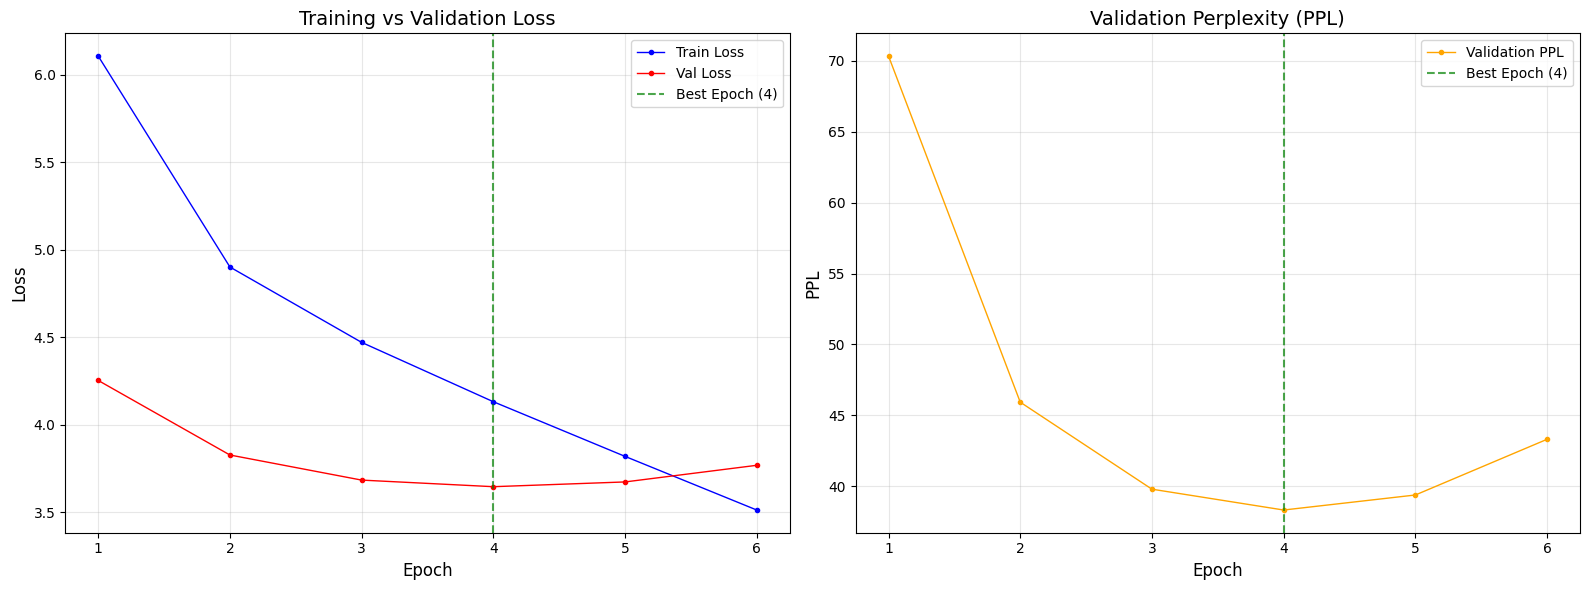

In [ ]:
import matplotlib.pyplot as plt
import re
import os

# 設定 Log 檔案路徑
log_path = "training_log.txt"

# 準備空串列來存數據
epochs = []
train_losses = []
val_losses = []
ppls = []

# 檢查檔案是否存在
if not os.path.exists(log_path):
    print(f"❌ 找不到 {log_path}！請確認你有跑過訓練並產生這個檔案。")
else:
    print(f"📂 正在讀取 {log_path}...")
    
    with open(log_path, "r") as f:
        for line in f:
            # [大哥修改] 這裡更新了正則表達式，對應你最新的 Log 格式
            # 格式範例: Epoch 1/15 | Train: 6.4615 | Val: 4.3856 | PPL: 80.29 | ...
            match = re.search(r"Epoch (\d+)/(\d+) \| Train: ([\d\.]+) \| Val: ([\d\.]+) \| PPL: ([\d\.]+)", line)
            
            if match:
                epoch = int(match.group(1))
                train_loss = float(match.group(3))
                val_loss = float(match.group(4))
                ppl = float(match.group(5))
                
                epochs.append(epoch)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                ppls.append(ppl)

    # 開始畫圖
    if not epochs:
        print("⚠️ 檔案裡沒讀到任何數據，請檢查 log 格式是否正確。")
    else:
        print(f"✅ 成功讀取 {len(epochs)} 輪的數據，正在繪圖...")
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # --- 第一張圖：Loss 曲線 ---
        ax1.plot(epochs, train_losses, label='Train Loss', marker='.', color='blue', linestyle='-', linewidth=1)
        ax1.plot(epochs, val_losses, label='Val Loss', marker='.', color='red', linestyle='-', linewidth=1)
        
        # 自動抓出 Val Loss 最低的那一點
        min_val_loss = min(val_losses)
        best_epoch_loss = epochs[val_losses.index(min_val_loss)]
        
        ax1.axvline(x=best_epoch_loss, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch_loss})')
        ax1.set_title('Training vs Validation Loss', fontsize=14)
        ax1.set_xlabel('Epoch', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # --- 第二張圖：PPL 曲線 ---
        ax2.plot(epochs, ppls, label='Validation PPL', marker='.', color='orange', linestyle='-', linewidth=1)
        
        # 自動抓出 PPL 最低的那一點
        min_ppl = min(ppls)
        best_epoch_ppl = epochs[ppls.index(min_ppl)]
        
        ax2.axvline(x=best_epoch_ppl, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch_ppl})')
        ax2.set_title('Validation Perplexity (PPL)', fontsize=14)
        ax2.set_xlabel('Epoch', fontsize=12)
        ax2.set_ylabel('PPL', fontsize=12)
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        
        # 存檔與顯示
        plt.savefig('training_curve_auto.png')
        print("🎉 圖片已儲存為 'training_curve_auto.png'")
        plt.show()

In [ ]:
# --- 載入最好的模型 ---
model = Seq2SeqModelWithFlashAttn(
    transformer_model_path="answerdotai/ModernBERT-base",
    freeze_encoder=False,      # 👈 關鍵改動：不鎖 Encoder 了，讓它全動
    unfreeze_last_n_layers=22,  # 設為 0，因為上面已經設為 False (全開)
).to(device)

# 載入你剛剛訓練好的冠軍權重
load_checkpoint(model, Path("checkpoints/best.pt"), device) 
print("✅ 成功載入 best.pt，準備進行第二階段微調！")

🔥 正在為 Encoder 裝上 LoRA 渦輪增壓...
🔓 正在解鎖 Encoder 最後 22 層...
trainable params: 119,521,536 || all params: 158,205,696 || trainable%: 75.5482
✅ 成功載入 best.pt，準備進行第二階段微調！


In [ ]:
# 2. 重新建立 訓練集 (Train)
print("📂 正在重新讀取訓練集 (Train Set)...")
train_set = build_dataset(
    ["dataset/tifu/tifu_train.jsonl", "dataset/samsun/train.csv"],
    tokenizer=model.tokenizer,
)
train_loader = build_dataloader(
    train_set,
    batch_size=batch_size,
    shuffle=True, # 訓練要洗牌
    num_workers=num_workers,
)

# 3. 重新建立 驗證集 (Validation) - 等等驗證會用到
print("📂 正在重新讀取驗證集 (Val Set)...")
val_set = build_dataset(
    ["dataset/tifu/tifu_val.jsonl", "dataset/samsun/validation.csv"],
    tokenizer=model.tokenizer,
)
valid_loader = build_dataloader(
    val_set,
    batch_size=batch_size,
    shuffle=False, # 驗證不洗牌
    num_workers=num_workers,
)

print(f"✅ 資料載入完成！train_loader 長度: {len(train_loader)}")

📂 正在重新讀取訓練集 (Train Set)...
Built dataset with 44199 samples.
📂 正在重新讀取驗證集 (Val Set)...
Built dataset with 5026 samples.
✅ 資料載入完成！train_loader 長度: 11050


In [ ]:
# --- 修改學習率與 Epoch ---
lr_finetune = 1e-5  # 👈 超小火慢燉
epochs = 5          # 不用多，跑個 3-5 輪看看有沒有提升就好
checkpoint_path = Path("checkpoints/best_finetuned.pt") # 改個名字存，不要蓋掉原本的 best.pt
best_checkpoint_path = Path("checkpoints/best_finetuned.pt")

# 重新定義優化器 (因為參數解鎖狀況變了，要重新抓)
encoder_params = []
decoder_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if "encoder" in name:
            encoder_params.append(param)
        else:
            decoder_params.append(param)

optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': lr_finetune},      # Encoder 用極小 LR
    {'params': decoder_params, 'lr': lr_finetune * 2}   # Decoder 可以稍微大一點點，或是一樣
], weight_decay=0.01) # weight_decay 也可以稍微調小一點

# Scheduler 也要重設
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=100, # 稍微 warmup 一下就好
    num_training_steps=int(epochs * len(train_loader) / 4), 
)

# 記得重置最佳成績紀錄，不然不會存檔
best_val_ppl = float("inf")

In [ ]:
import time
import math

# ------------------------------------------------------------------
# 🔥 開始微調訓練迴圈
# ------------------------------------------------------------------

# 設定 Log 檔案 (建議分開存，比較好觀察差異)
log_path = "finetune_log.txt"
with open(log_path, "w") as f:
    f.write("Epoch, Train Loss, Val Loss, PPL, Time, LR_Enc, LR_Dec\n")

# Early Stopping 設定
patience = 2          
patience_counter = 0  
best_val_loss = float("inf") # 重置，因為我們要看這次微調能不能更好

print(f"🚀 開始微調 (Fine-tuning)！總共 {epochs} 輪，Patience = {patience}")

for epoch in range(1, epochs + 1):
    start_time = time.time()
    
    # --- 1. 訓練 (Train) ---
    train_loss, _ = run_epoch(
        train_loader,
        model,
        device,
        optimizer,
        scheduler,
        model.tokenizer.pad_token_id,
        max_grad_norm=1.0, # 保持原本的梯度裁剪
        train=True,
        tokenizer=model.tokenizer 
    )
    
    # --- 2. 驗證 (Validation) ---
    with torch.no_grad():
        val_loss, val_rouge = run_epoch(
            valid_loader,
            model,
            device,
            optimizer=None,
            scheduler=None,
            pad_id=model.tokenizer.pad_token_id,
            max_grad_norm=1.0,
            train=False,
            tokenizer=model.tokenizer 
        )
    
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)
    time_str = f"{int(epoch_mins)}m {int(epoch_secs)}s"
    
    # 抓出目前的學習率 (方便觀察有沒有真的變很小)
    current_lr_enc = optimizer.param_groups[0]['lr']
    current_lr_dec = optimizer.param_groups[1]['lr']

    perplexity = math.exp(min(20, val_loss))
    current_val_ppl = perplexity
    
    # 印出進度
    msg = (f"Epoch {epoch}/{epochs} | "
           f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
           f"PPL: {perplexity:.2f} | "
           f"Time: {time_str} | "
           f"LR_Enc: {current_lr_enc:.2e}")
    
    print(msg)
    
    with open(log_path, "a") as f:
        f.write(msg + "\n")
    
    # ---------------------------------------------------
    # 存檔策略: 只存 Best (看 PPL)
    # ---------------------------------------------------
    if current_val_ppl < best_val_ppl:
        best_val_ppl = current_val_ppl
        
        # 這裡會存到 checkpoints/best_finetuned.pt
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            path=best_checkpoint_path, 
            epoch=epoch,
        )
        print(f"🏆 微調突破！新紀錄 PPL: {best_val_ppl:.2f}，已存檔！")
        with open(log_path, "a") as f:
            f.write(f"*** New Best PPL: {best_val_ppl:.2f} ***\n")

    # ---------------------------------------------------
    # Early Stopping 邏輯
    # ---------------------------------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0 
    else:
        patience_counter += 1 
        print(f"⚠️ 警告：微調效果沒變好 ({val_loss:.4f})。累積失望次數: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"🛑 微調結束！模型已經學不動了。")
            break

print("🎉 微調完成！請使用 checkpoints/best_finetuned.pt 進行預測。")

🚀 開始微調 (Fine-tuning)！總共 5 輪，Patience = 2


Epoch 1/5 | Train: 3.7074 | Val: 3.6376 | PPL: 38.00 | Time: 13m 10s | LR_Enc: 9.10e-06
🏆 微調突破！新紀錄 PPL: 38.00，已存檔！


Epoch 2/5 | Train: 3.6696 | Val: 3.6407 | PPL: 38.12 | Time: 13m 9s | LR_Enc: 6.61e-06
⚠️ 警告：微調效果沒變好 (3.6407)。累積失望次數: 1/2


Epoch 3/5 | Train: 3.6613 | Val: 3.6409 | PPL: 38.13 | Time: 13m 9s | LR_Enc: 3.50e-06
⚠️ 警告：微調效果沒變好 (3.6409)。累積失望次數: 2/2
🛑 微調結束！模型已經學不動了。
🎉 微調完成！請使用 checkpoints/best_finetuned.pt 進行預測。


In [ ]:
import os

# 1. 設定模型路徑
# 如果你確定微調後的 PPL 比較低（例如降到了 36 或 35），就用這個新檔案
finetuned_path = Path("checkpoints/best_finetuned.pt")
original_path = Path("checkpoints/best.pt")

# 2. 簡單的防呆判斷 (大哥建議你自己手動確認一下 log 比較準)
if finetuned_path.exists():
    print(f"😎 發現微調後的模型：{finetuned_path}")
    print("👉 正在載入 best_finetuned.pt ...")
    load_checkpoint(model, finetuned_path, device)
else:
    print(f"⚠️ 找不到微調模型，將使用原始最佳模型：{original_path}")
    load_checkpoint(model, original_path, device)

# 3. 確保進入評估模式 (這很重要！)
model.eval()

print("✅ 模型載入完成！可以開始 Grid Search 了！")

😎 發現微調後的模型：checkpoints/best_finetuned.pt
👉 正在載入 best_finetuned.pt ...
✅ 模型載入完成！可以開始 Grid Search 了！


# Grid Search

In [ ]:

print("📂 正在重新讀取驗證集...")
val_set = build_dataset(
    ["dataset/tifu/tifu_val.jsonl", "dataset/samsun/validation.csv"],
    tokenizer=model.tokenizer,
)

valid_loader = build_dataloader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

print("✅ valid_loader 復活了！請繼續執行下面的 Grid Search。")

📂 正在重新讀取驗證集...
Built dataset with 5026 samples.
✅ valid_loader 復活了！請繼續執行下面的 Grid Search。


## Predict Result

Predict the labesl based on testing set. Upload to [Kaggle](https://www.kaggle.com/t/efb569a4c0774de681e9f8426cfac364).

**How to upload**

1. To kaggle. Click "Submit Predictions"
2. Upload the result.csv
3. System will automaticlaly calculate the accuracy of 50% dataset and publish this result to leaderboard.

In [ ]:
# 1. 載入最好的模型 (Best Checkpoint)
# 確保 PREDICT_CHECKPOINT 指向的是 best.pt (例如 checkpoints/best.pt)
load_checkpoint(model, BEST_CHECKPOINT_PATH, device)
model.eval()

# 2. 建立測試資料集
test_set = build_dataset(
    [TIFU_TEST_PATH, SAMSUN_TEST_PATH],
    tokenizer=model.tokenizer,
    require_target=False,
)

# 3. [加速重點] 建立 DataLoader
# Inference 不用算梯度，顯卡很空，Batch Size 開到 100 沒問題
test_loader = build_dataloader(
    test_set,
    batch_size=128,   
    shuffle=False,
    num_workers=4,    
)

predictions: List[Tuple[str, str]] = []

print("🚀 開始預測... (請確認 beam_size 設定)")

with torch.no_grad():
    # 4. [加速重點] 開啟 AMP (bfloat16)
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        
        for i, sample in enumerate(tqdm(test_loader, desc="predict", leave=False)):
            input_ids = sample["src"].to(device)
            src_lens = sample["src_len"].to(device=device, dtype=torch.int32)
            ids = sample["id"]
            
            summaries = model.generate(
                input_ids=input_ids,
                src_seq_len=src_lens,
                
                # --- 生成長度限制 ---
                generation_limit=100, # 摘要不用寫太長，設 100~128 夠用了
                
                # --- 關鍵生成參數 ---
                sampling=False,          # 建議關閉抽樣，追求穩定高分
                beam_size=1,             # [重點] 1=Greedy(快), 4=BeamSearch(準但慢)
                repetition_penalty=1.2,  # 防止鬼打牆的神技
                no_repeat_ngram=3,       # 禁止連續 3 個字完全重複
                min_len=10,              # 避免生成太短的句子
                len_penalty=1.0          # (Beam Search 專用) 鼓勵長句
            )
            
            # 偷看一下第一筆結果，確認它不是在講外星語
            if i == 0:
                print("------------------------------------------------")
                print(f"【預覽摘要】: {summaries[0]}")
                print("------------------------------------------------")
                
            predictions.extend(zip(ids, summaries))

# 5. 存檔
output_path = PREDICTION_OUTPUT
write_predictions_csv(output_path, predictions)
print(f"✅ 搞定！寫入 {len(predictions)} 筆預測結果到 {output_path}")

Built dataset with 9248 samples.
🚀 開始預測... (請確認 beam_size 設定)


predict:   1%|▏         | 1/73 [00:06<07:30,  6.26s/it]

------------------------------------------------
【預覽摘要】: tried to stop a girl cry, ended up making her cry.
------------------------------------------------


✅ 搞定！寫入 9248 筆預測結果到 result2.csv
